In [ ]:
import pandas as pd
from collections import Counter 
import math
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from shapely.geometry import Point
import os
import netCDF4 as nc
import pandas as pd
import xarray as xr
from datetime import datetime
import rasterio
from tqdm import tqdm
from shapely.geometry import box
from collections import defaultdict
import calendar
from rasterio.transform import from_origin
from matplotlib.animation import FuncAnimation, PillowWriter
from tqdm import tqdm
from glob import glob
from PIL import Image
from rasterio.mask import mask
from PIL import Image, ImageDraw, ImageFont
import json


In [16]:
gdf_idf = gpd.read_file(r"R:\Direction_Data\0_Projets\Projet_CANCAIR\Canc_air_Loice\geocodeur\from_hegp\data\zones_geographiques\departements\IDF\dpt_idf.shp")
target_crs = 'EPSG:27572'  

# Reprojeter le shapefile IDF vers le CRS cible
gdf_idf = gdf_idf.to_crs(target_crs)

In [17]:
# Chemin du répertoire contenant les fichiers .nc
repertoire = r"R:\Direction_Data\0_Projets\Projet_CANCAIR\data\airparif_dir\airparif\pollution"

In [18]:
def extract_date_from_filename(filename):
    """
    Extrait l'année et le mois du nom de fichier au format PM10_meanJ_YYYYMMDD
    """
    date_str = filename.split('_')[-1].replace('.nc', '')  # Extraire la partie YYYYMMDD
    year = date_str[:4]
    month = date_str[4:6]
    return year, month

def process_files(files, pollutant, year, threshold_pm10=50, threshold_o3=180, output_dir=None):
    """
    Traite les fichiers de données de concentration de polluants pour calculer les jours de dépassement.

    Args:
        files (list): Liste des chemins de fichiers vers les fichiers de données de polluants.
        pollutant (str): Le type de polluant ('PM10' ou 'O3').
        year (str): L'année des données.
        threshold_pm10 (int, optional): Seuil de concentration pour PM10 (par défaut 50).
        threshold_o3 (int, optional): Seuil de concentration pour O3 (par défaut 180).
        output_dir (str, optional): Répertoire de sortie pour les fichiers TIFF des dépassements.

    Returns:
        dict: Dictionnaire contenant le nombre de jours de dépassement par mois.
    """
    monthly_exceedances = defaultdict(int)
    threshold = threshold_pm10 if pollutant == 'PM10' else threshold_o3

    # Initialise une variable pour stocker la somme des jours de dépassement par pixel
    sum_exceedances = None

    for file_path in tqdm(files, desc=f"Processing {pollutant} {year} files", unit="file"):
        try:
            ds = xr.open_dataset(file_path)
            data = ds[pollutant].values[0]  # Extrait la première étape temporelle

            exceedance_mask = (data > threshold).astype(np.uint8)

            # Accumule le masque de dépassement si sum_exceedances est initialisé
            if sum_exceedances is None:
                sum_exceedances = np.zeros_like(exceedance_mask, dtype=float)

            sum_exceedances += exceedance_mask

            if np.any(exceedance_mask):
                _, month = extract_date_from_filename(os.path.basename(file_path))
                monthly_exceedances[month] += 1

        except Exception as e:
            print(f"Erreur lors du traitement du fichier {file_path} : {e}")

    # Enregistre le résultat avec rasterio si nécessaire
    if output_dir and sum_exceedances is not None:
        # Extrait la transformation affine et le CRS de l'un des ensembles de données
        with xr.open_dataset(files[0]) as ds:
            lon = ds.coords['x'].values
            lat = ds.coords['y'].values
            transform = from_origin(lon.min(), lat.max(), lon[1] - lon[0], lat[1] - lat[0])
            crs = ds.attrs.get('crs', 'EPSG:27572')  # Utilise le CRS des données si disponible

        # Crée le chemin de sortie en incluant le seuil dans le nom du fichier
        output_path = os.path.join(output_dir, f"pic_{pollutant.lower()}_{year}_exceedances_threshold_{threshold}.tif")
        with rasterio.open(
            output_path,
            'w',
            driver='GTiff',
            height=sum_exceedances.shape[0],
            width=sum_exceedances.shape[1],
            count=1,
            dtype=sum_exceedances.dtype,
            crs=crs,
            transform=transform,
            compress='DEFLATE',
            zlevel=9
        ) as dst:
            dst.write(sum_exceedances, 1)

        print(f"Exceedance map for {pollutant} {year} with threshold {threshold} saved at {output_path}")

    return monthly_exceedances

def plot_exceedances(monthly_exceedances, pollutant, year):
    """
    Affiche un histogramme des jours de dépassement pour chaque mois.

    Args:
        monthly_exceedances (dict): Dictionnaire contenant le nombre de jours de dépassement par mois.
        pollutant (str): Le type de polluant ('PM10' ou 'O3').
        year (str): L'année des données.
    """
    # Noms des mois en français
    month_names = {
        '01': 'Janvier', '02': 'Février', '03': 'Mars', '04': 'Avril',
        '05': 'Mai', '06': 'Juin', '07': 'Juillet', '08': 'Août',
        '09': 'Septembre', '10': 'Octobre', '11': 'Novembre', '12': 'Décembre'
    }
    
    # Initialiser les valeurs de dépassement pour tous les mois
    full_monthly_exceedances = {month: 0 for month in month_names.keys()}
    full_monthly_exceedances.update(monthly_exceedances)

    # Trier les mois et récupérer les noms correspondants
    months = sorted(full_monthly_exceedances.keys())
    counts = [full_monthly_exceedances[month] for month in months]
    month_labels = [month_names[month] for month in months]

    plt.figure(figsize=(12, 6))
    plt.bar(month_labels, counts, color='skyblue')
    plt.xlabel('Mois')
    plt.ylabel('Nombre de jours de dépassement')
    plt.title(f'Nombre de jours de dépassement pour {pollutant} en {year}')
    plt.xticks(rotation=45)  # Tourner les étiquettes des mois pour qu'elles ne se chevauchent pas
    plt.tight_layout()       # Ajuster les marges pour une meilleure présentation
    plt.show()




In [19]:
# Paramètres de base
base_input_dir = r"R:\Direction_Data\0_Projets\Projet_CANCAIR\data\airparif_dir\airparif\pollution"
pollutants = ['PM10', 'O3']
years = ["2017", "2018", "2019"]
output_dir = r"R:\Direction_Data\0_Projets\Projet_CANCAIR\data\airparif_dir\airparif\exceedances"
os.makedirs(output_dir, exist_ok=True)

Processing PM10 2017 files: 100%|██████████| 365/365 [02:27<00:00,  2.47file/s]


Exceedance map for PM10 2017 with threshold 50 saved at R:\Direction_Data\0_Projets\Projet_CANCAIR\data\airparif_dir\airparif\exceedances\pic_pm10_2017_exceedances_threshold_50.tif


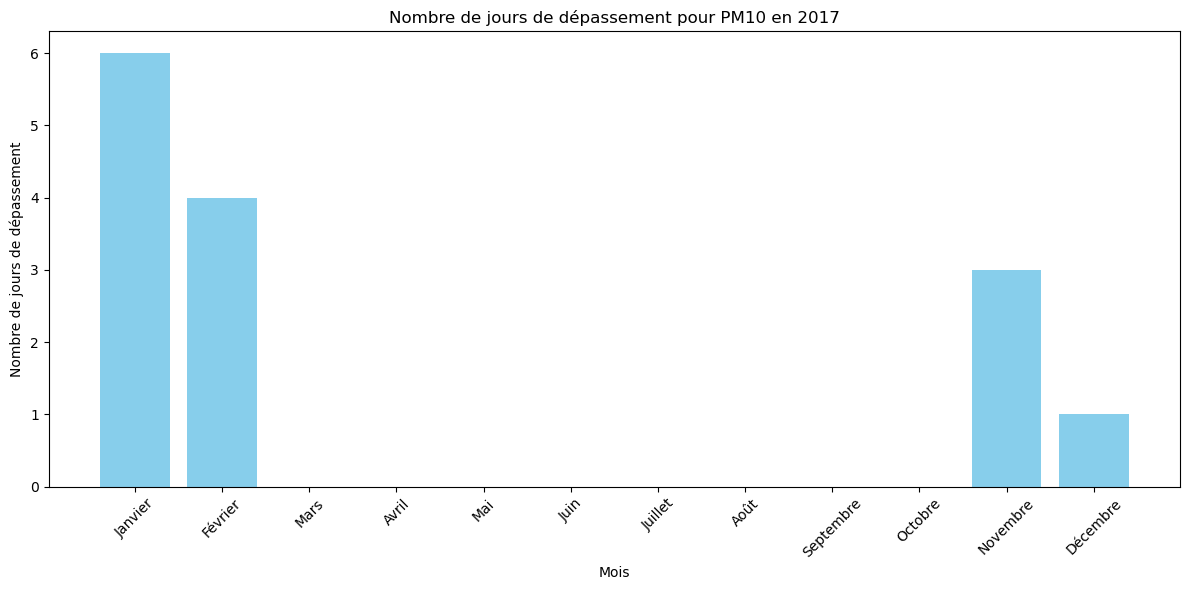

Processing O3 2017 files: 100%|██████████| 365/365 [03:00<00:00,  2.02file/s]


Exceedance map for O3 2017 with threshold 180 saved at R:\Direction_Data\0_Projets\Projet_CANCAIR\data\airparif_dir\airparif\exceedances\pic_o3_2017_exceedances_threshold_180.tif


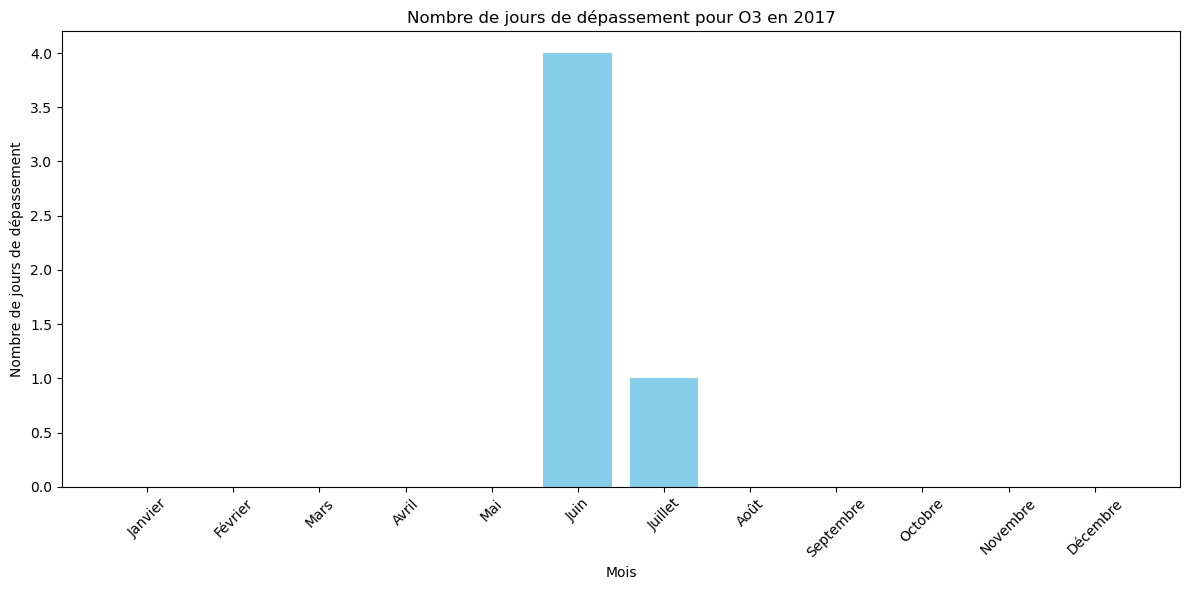

Processing PM10 2018 files: 100%|██████████| 365/365 [02:14<00:00,  2.71file/s]


Exceedance map for PM10 2018 with threshold 50 saved at R:\Direction_Data\0_Projets\Projet_CANCAIR\data\airparif_dir\airparif\exceedances\pic_pm10_2018_exceedances_threshold_50.tif


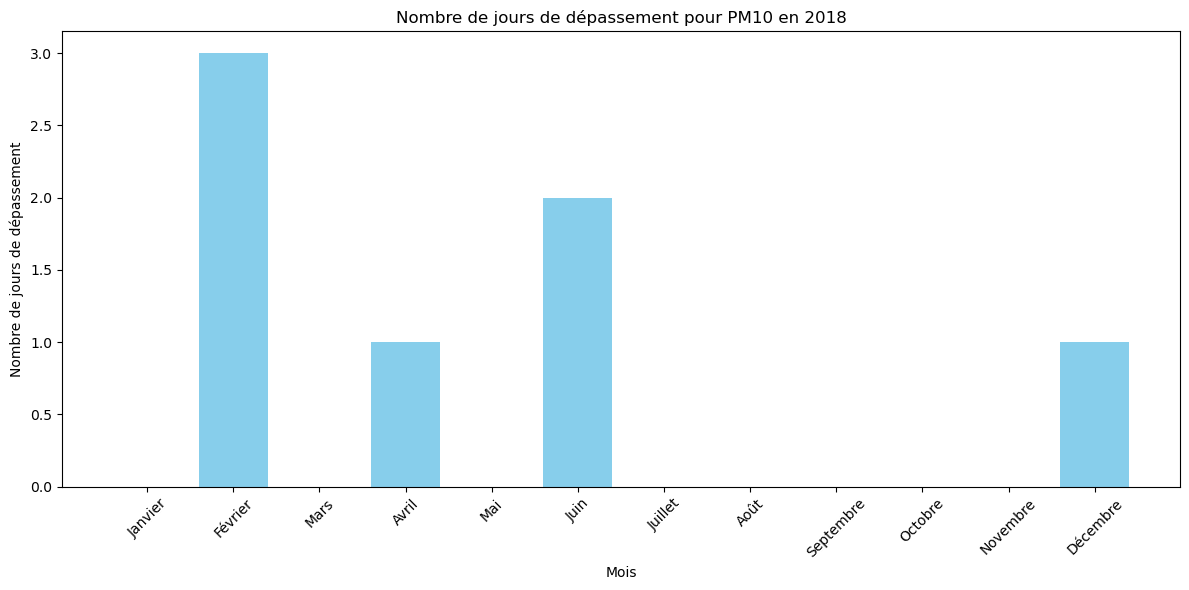

Processing O3 2018 files: 100%|██████████| 365/365 [03:05<00:00,  1.96file/s]


Exceedance map for O3 2018 with threshold 180 saved at R:\Direction_Data\0_Projets\Projet_CANCAIR\data\airparif_dir\airparif\exceedances\pic_o3_2018_exceedances_threshold_180.tif


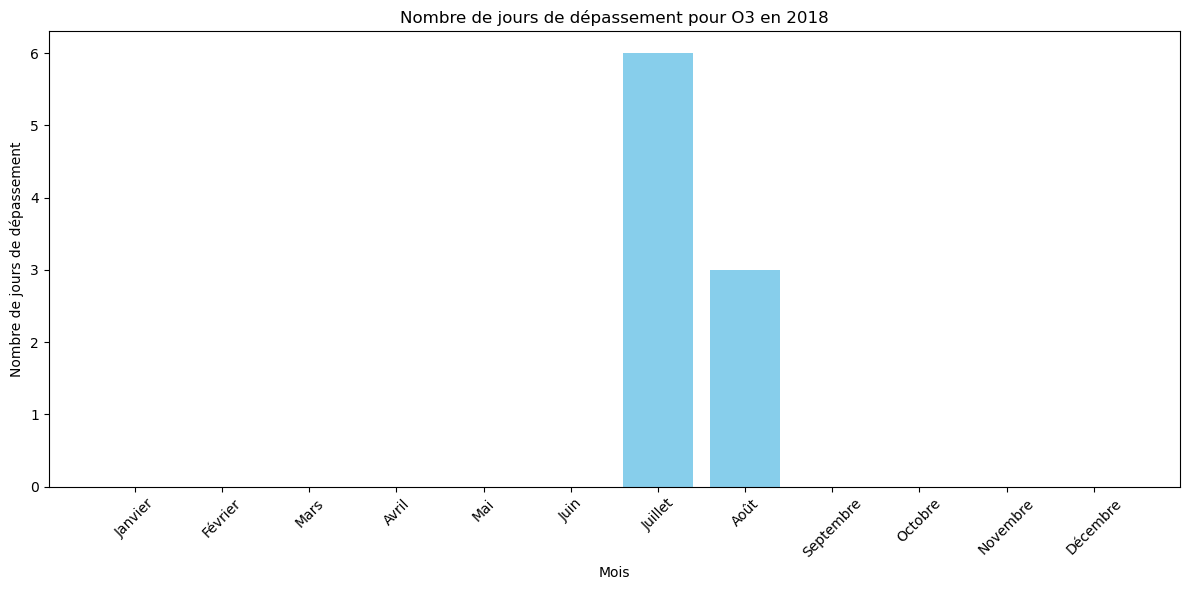

Processing PM10 2019 files: 100%|██████████| 365/365 [02:27<00:00,  2.47file/s]


Exceedance map for PM10 2019 with threshold 50 saved at R:\Direction_Data\0_Projets\Projet_CANCAIR\data\airparif_dir\airparif\exceedances\pic_pm10_2019_exceedances_threshold_50.tif


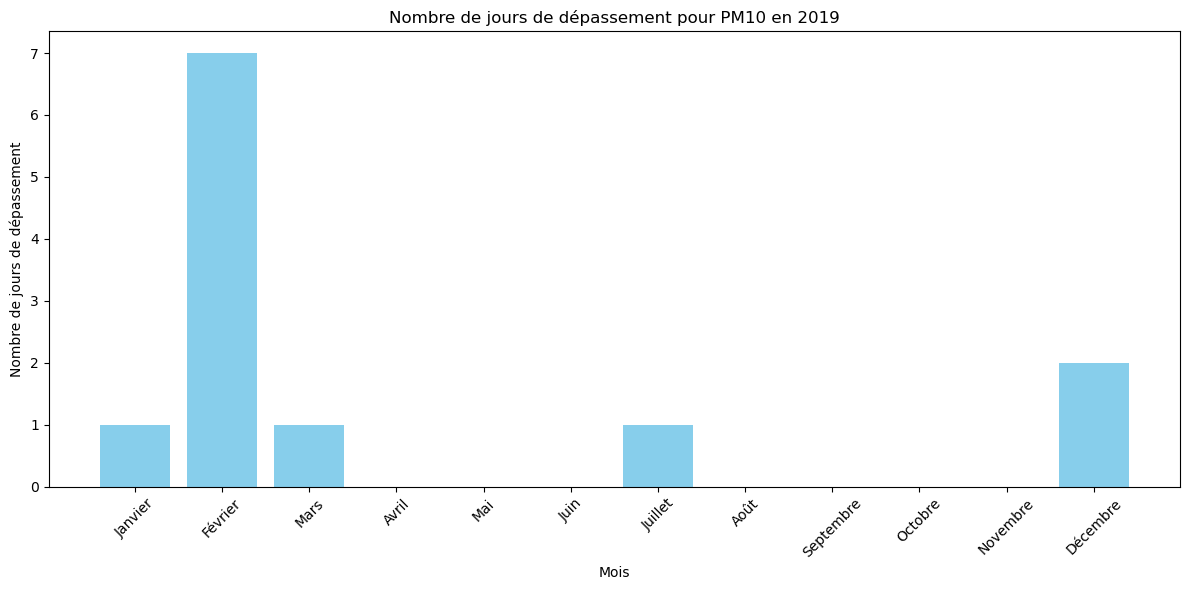

Processing O3 2019 files: 100%|██████████| 365/365 [03:14<00:00,  1.88file/s]


Exceedance map for O3 2019 with threshold 180 saved at R:\Direction_Data\0_Projets\Projet_CANCAIR\data\airparif_dir\airparif\exceedances\pic_o3_2019_exceedances_threshold_180.tif


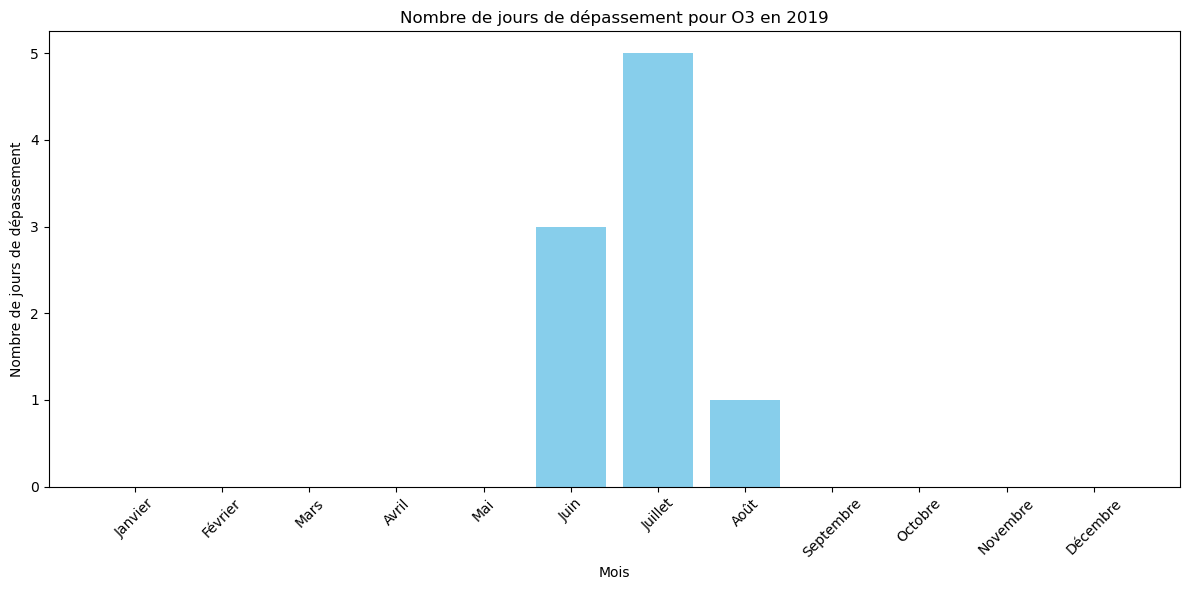

In [20]:
# Traiter les fichiers pour chaque polluant et chaque année
all_monthly_exceedances = defaultdict(lambda: defaultdict(dict))

for year in years:
    input_dir = os.path.join(base_input_dir, year)
    for pollutant in pollutants:
        files = [os.path.join(input_dir, file) for file in os.listdir(input_dir)
                 if file.endswith('.nc') and pollutant in file]
        
        if files:
            monthly_exceedances = process_files(files, pollutant, year, output_dir=output_dir)
            all_monthly_exceedances[year][pollutant] = monthly_exceedances
            plot_exceedances(monthly_exceedances, pollutant, year)
        else:
            print(f"No files found for {pollutant} in {year}.")

In [22]:
df = pd.read_csv(r"H:\PFE Loice\Notebooks\data\data_cleaned\patients_FR_IDF_geocoded_adulte_clinique.csv",sep=";")
df_EM = pd.read_csv(r"H:\PFE Loice\Notebooks\Loice_Canc-air_2025\cancair_stage_ete_2024\geocodeur\from_hegp\data\data_octobre_2023\medical_event\medical_events_all.csv", sep = ",")

In [23]:
id_patients = df['pseudo_provisoire'].tolist()
df_EM_id = df_EM[df_EM['pseudo_provisoire'].isin(id_patients)]

df_EM_geodata = pd.merge(df_EM_id,df[['pseudo_provisoire','x','y']], on='pseudo_provisoire',how="left")

def parse_dates(date_str):
    try:
        return pd.to_datetime(date_str, format='%Y-%m-%d %H:%M:%S')
    except ValueError:
        return pd.to_datetime(date_str, format='%d/%m/%Y')

df_EM_geodata['standardized_dates'] = df_EM_geodata['Date_debut'].apply(parse_dates)

df_EM_geodata['standardized_dates'] = df_EM_geodata['standardized_dates'].dt.strftime('%Y-%m-%d')

In [25]:
# Répertoire de base pour les données d'entrée et de sortie
base_input_dir = r"R:\Direction_Data\0_Projets\Projet_CANCAIR\data\airparif_dir\airparif\pollution"
output_dir_base = r"R:\Direction_Data\0_Projets\Projet_CANCAIR\data\airparif_dir\airparif\pollution"

# Chemin vers le shapefile de l'IDF
idf_shapefile = r"R:\Direction_Data\0_Projets\Projet_CANCAIR\Canc_air_Loice\geocodeur\from_hegp\data\zones_geographiques\departements\IDF\dpt_idf.shp"

# Charger le shapefile avec geopandas
idf_gdf = gpd.read_file(idf_shapefile)

# Définir le CRS cible (CRS de vos données TIFF, EPSG:27572 pour Lambert II)
target_crs = 'EPSG:27572'

# Reprojeter le shapefile IDF vers le CRS cible
idf_gdf = idf_gdf.to_crs(target_crs)

def cut_and_overlay_shapefile(tiff_file, shapefile, output_file):
    """
    Découpe le fichier TIFF selon le shapefile et ajoute les limites administratives.
    
    Args:
        tiff_file (str): Chemin vers le fichier TIFF à découper.
        shapefile (GeoDataFrame): GeoDataFrame avec les limites administratives.
        output_file (str): Chemin vers le fichier TIFF découpé et annoté à enregistrer.
    """
    with rasterio.open(tiff_file) as src:
        image_array = src.read(1)
        transform = src.transform
        crs = src.crs

        # Découpe avec le shapefile
        out_image, out_transform = mask(src, shapefile.geometry, crop=True)
        
        # Mettre à jour les métadonnées
        out_meta = src.meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "count": 1,
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })
        
        # Enregistrer le TIFF découpé
        with rasterio.open(output_file, "w", **out_meta) as dest:
            dest.write(out_image, 1)
        
        # Ajouter les limites administratives à l'image
        with rasterio.open(output_file) as src:
            img = Image.open(src.name)
            draw = ImageDraw.Draw(img)
            for _, row in shapefile.iterrows():
                geom = row['geometry']
                coords = [(x, y) for x, y in zip(*geom.exterior.xy)]
                draw.line(coords, fill="red", width=2)
            img.save(output_file)

def add_date_to_image(image_file, date_str, output_file):
    """
    Ajoute la date au fichier image.
    
    Args:
        image_file (str): Chemin vers le fichier image.
        date_str (str): Date à ajouter.
        output_file (str): Chemin vers le fichier image avec la date ajoutée.
    """
    img = Image.open(image_file)
    draw = ImageDraw.Draw(img)
    font = ImageFont.load_default()
    text_width, text_height = draw.textsize(date_str, font=font)
    width, height = img.size
    text_x = width - text_width - 10
    text_y = height - text_height - 10
    draw.text((text_x, text_y), date_str, font=font, fill="white")
    img.save(output_file)

def create_gif_with_pillow(tiff_files, gif_filename, duration=0.5):
    """
    Crée un GIF à partir des fichiers TIFF en utilisant Pillow.
    
    Args:
        tiff_files (list): Liste des chemins des fichiers TIFF.
        gif_filename (str): Nom du fichier GIF de sortie.
        duration (float, optional): Durée de chaque image dans le GIF (en secondes).
    """
    images = []
    for tiff_file in tqdm(tiff_files, desc="Creating GIF", unit="file"):
        img = Image.open(tiff_file)
        images.append(img)
    
    images[0].save(gif_filename, save_all=True, append_images=images[1:], duration=int(duration * 1000), loop=0)
    print(f"GIF créé : {gif_filename}")


# Exemple d'utilisation
years = ['2017', '2018', '2019']
pollutants = ['PM10', 'O3']
thresholds = {'PM10': 50, 'O3': 180}

for year in years:
    input_dir = os.path.join(base_input_dir, year)
    for pollutant in pollutants:
        threshold = thresholds[pollutant]
        output_dir = os.path.join(output_dir_base, f"{pollutant}_{year}_pic")
        
        # Récupérer tous les fichiers correspondant au polluant et à l'année
        files = [os.path.join(input_dir, file) for file in os.listdir(input_dir)
                 if file.endswith('.nc') and pollutant in file]

        if files:
            tiff_files = process_files(files, pollutant, year, threshold_pm10=threshold if pollutant == 'PM10' else None, threshold_o3=threshold if pollutant == 'O3' else None, output_dir=output_dir)
            
            if tiff_files:
                # Découpe les TIFF selon l'emprise de l'IDF et ajoute les limites administratives
                cut_tiff_files = []
                for tiff_file in tiff_files:
                    cut_file = os.path.join(output_dir, os.path.basename(tiff_file).replace('.tif', '_cut.tif'))
                    cut_and_overlay_shapefile(tiff_file, idf_gdf, cut_file)
                    cut_tiff_files.append(cut_file)

                # Ajoute la date sur chaque image
                dated_tiff_files = []
                for tiff_file in cut_tiff_files:
                    date_str = extract_date_from_filename(os.path.basename(tiff_file))
                    dated_file = os.path.join(output_dir, os.path.basename(tiff_file).replace('.tif', '_dated.tif'))
                    add_date_to_image(tiff_file, date_str, dated_file)
                    dated_tiff_files.append(dated_file)

                # Crée le GIF
                create_gif_with_pillow(dated_tiff_files, os.path.join(output_dir_base, f"{pollutant}_{year}_pic.gif"))



Processing PM10 2017 files: 100%|██████████| 365/365 [02:14<00:00,  2.71file/s]


RasterioIOError: Attempt to create new tiff file 'R:\Direction_Data\0_Projets\Projet_CANCAIR\data\airparif_dir\airparif\pollution\PM10_2017_pic\pic_pm10_2017_exceedances_threshold_50.tif' failed: No such file or directory

In [ ]:

# Répertoire de base pour les données d'entrée et de sortie
base_input_dir = "data/airparif_dir/airparif/pollution/"
output_dir_base = "data/airparif_dir/airparif/pollution/"

# Chemin vers le shapefile de l'IDF
idf_shapefile = "../geocodeur/from_hegp/data/zones_geographiques/departements/IDF/dpt_idf.shp"

# Charger le shapefile avec geopandas
idf_gdf = gpd.read_file(idf_shapefile)

# Définir le CRS cible (CRS de vos données TIFF, EPSG:27572 pour Lambert II)
target_crs = 'EPSG:27572'

# Reprojeter le shapefile IDF vers le CRS cible
idf_gdf = idf_gdf.to_crs(target_crs)

def cut_and_overlay_shapefile(tiff_file, shapefile, output_file):
    """
    Découpe le fichier TIFF selon le shapefile et ajoute les limites administratives.
    
    Args:
        tiff_file (str): Chemin vers le fichier TIFF à découper.
        shapefile (GeoDataFrame): GeoDataFrame avec les limites administratives.
        output_file (str): Chemin vers le fichier TIFF découpé et annoté à enregistrer.
    """
    with rasterio.open(tiff_file) as src:
        image_array = src.read(1)
        transform = src.transform
        crs = src.crs

        # Découpe avec le shapefile
        out_image, out_transform = mask(src, shapefile.geometry, crop=True)
        
        # Mettre à jour les métadonnées
        out_meta = src.meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "count": 1,
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })
        
        # Enregistrer le TIFF découpé
        with rasterio.open(output_file, "w", **out_meta) as dest:
            dest.write(out_image, 1)
        
        # Ajouter les limites administratives à l'image
        with rasterio.open(output_file) as src:
            img = Image.open(src.name)
            draw = ImageDraw.Draw(img)
            for _, row in shapefile.iterrows():
                geom = row['geometry']
                coords = [(x, y) for x, y in zip(*geom.exterior.xy)]
                draw.line(coords, fill="red", width=2)
            img.save(output_file)

def add_date_to_image(image_file, date_str, output_file):
    """
    Ajoute la date au fichier image.
    
    Args:
        image_file (str): Chemin vers le fichier image.
        date_str (str): Date à ajouter.
        output_file (str): Chemin vers le fichier image avec la date ajoutée.
    """
    img = Image.open(image_file)
    draw = ImageDraw.Draw(img)
    font = ImageFont.load_default()
    text_width, text_height = draw.textsize(date_str, font=font)
    width, height = img.size
    text_x = width - text_width - 10
    text_y = height - text_height - 10
    draw.text((text_x, text_y), date_str, font=font, fill="white")
    img.save(output_file)

def create_gif_with_pillow(tiff_files, gif_filename, duration=0.5):
    """
    Crée un GIF à partir des fichiers TIFF en utilisant Pillow.
    
    Args:
        tiff_files (list): Liste des chemins des fichiers TIFF.
        gif_filename (str): Nom du fichier GIF de sortie.
        duration (float, optional): Durée de chaque image dans le GIF (en secondes).
    """
    images = []
    for tiff_file in tqdm(tiff_files, desc="Creating GIF", unit="file"):
        img = Image.open(tiff_file)
        images.append(img)
    
    images[0].save(gif_filename, save_all=True, append_images=images[1:], duration=int(duration * 1000), loop=0)
    print(f"GIF créé : {gif_filename}")



def process_files(files, pollutant, year, threshold, output_dir=None):
    """
    Traite les fichiers de données de concentration de polluants pour enregistrer les masques binaires.
    
    Args:
        files (list): Liste des chemins de fichiers vers les fichiers de données de polluants.
        pollutant (str): Le type de polluant ('PM10' ou 'O3').
        year (str): L'année des données.
        threshold (int): Seuil de concentration pour le polluant.
        output_dir (str, optional): Répertoire de sortie pour les fichiers TIFF des masques binaires.
    
    Returns:
        list: Liste des chemins des fichiers TIFF créés.
    """
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    tiff_files = []

    for file_path in tqdm(files, desc=f"Processing {pollutant} {year} files", unit="file"):
        try:
            # Lire le fichier NetCDF avec xarray
            ds = xr.open_dataset(file_path)
            data = ds[pollutant].values[0]  # Extrait la première étape temporelle

            # Appliquer le masque binaire
            exceedance_mask = np.where(data > threshold, 255, 0).astype(np.uint8)

            # Extraire les coordonnées et la transformation affine
            lon_min, lat_max = ds.coords['x'].values[0], ds.coords['y'].values[0]
            lon_res, lat_res = ds.coords['x'].values[1] - ds.coords['x'].values[0], ds.coords['y'].values[1] - ds.coords['y'].values[0]
            transform = from_origin(lon_min, lat_max, lon_res, lat_res)
            crs = ds.attrs.get('crs', 'EPSG:27572')  # Utiliser le CRS des données ou le CRS cible

            # Créer le chemin de sortie en incluant le seuil dans le nom du fichier
            output_filename = os.path.basename(file_path).replace('.nc', f'_{threshold}.tif')
            output_path = os.path.join(output_dir, output_filename)

            # Enregistrer le masque binaire en TIFF
            with rasterio.open(
                output_path,
                'w',
                driver='GTiff',
                height=exceedance_mask.shape[0],
                width=exceedance_mask.shape[1],
                count=1,
                dtype=exceedance_mask.dtype,
                crs=crs,
                transform=transform,
                compress='DEFLATE',
                zlevel=9
            ) as dst:
                dst.write(exceedance_mask, 1)

            tiff_files.append(output_path)
            print(f"Masque binaire pour {pollutant} {year} avec seuil {threshold} enregistré à {output_path}")

        except Exception as e:
            print(f"Erreur lors du traitement du fichier {file_path} : {e}")

    return tiff_files

# Exemple d'utilisation
years = ['2017', '2018', '2019']
pollutants = ['PM10', 'O3']
thresholds = {'PM10': 50, 'O3': 180}

for year in years:
    input_dir = os.path.join(base_input_dir, year)
    for pollutant in pollutants:
        threshold = thresholds[pollutant]
        output_dir = os.path.join(output_dir_base, f"{pollutant}_{year}_pic")

for year in years:
    input_dir = os.path.join(base_input_dir, year)
    for pollutant in pollutants:
        threshold = thresholds[pollutant]
        # Créer un répertoire de sortie spécifique pour chaque seuil
        output_dir = os.path.join(output_dir_base, f"{pollutant}_{year}_{threshold}_pic")
            
        # Récupérer tous les fichiers correspondant au polluant, à l'année, et au seuil
        files = [os.path.join(input_dir, file) for file in os.listdir(input_dir)
                    if file.endswith('.nc') and pollutant in file]

        if files:
            tiff_files = process_files(files, pollutant, year, threshold, output_dir=output_dir)
                
            if tiff_files:
                # Découpe les TIFF selon l'emprise de l'IDF et ajoute les limites administratives
                cut_tiff_files = []
                for tiff_file in tiff_files:
                    cut_file = os.path.join(output_dir, os.path.basename(tiff_file).replace('.tif', '_cut.tif'))
                    cut_and_overlay_shapefile(tiff_file, idf_gdf, cut_file)
                    cut_tiff_files.append(cut_file)
                    
                # Ajouter la date à chaque image et créer un GIF
                dated_tiff_files = []
                for tiff_file in cut_tiff_files:
                    date_str = extract_date_from_filename(os.path.basename(tiff_file))
                    dated_file = os.path.join(output_dir, os.path.basename(tiff_file).replace('.tif', '_dated.tif'))
                    add_date_to_image(tiff_file, date_str, dated_file)
                    dated_tiff_files.append(dated_file)
                    
                    # Créer le GIF pour les fichiers avec date
                    if dated_tiff_files:
                        create_gif_with_pillow(dated_tiff_files, os.path.join(output_dir, f"{pollutant}_{year}_{threshold}_pic.gif"))


# NOMBRE DE PICS PAR MOIS

In [ ]:
import os
import pandas as pd
import xarray as xr
from tqdm import tqdm
import calendar

# Définir les seuils pour les polluants
thresholds = {'PM10': 40, 'O3': 140}

def extract_date_from_filename(filename):
    """
    Extrait l'année et le mois du nom de fichier au format PM10_meanJ_YYYYMMDD
    """
    date_str = filename.split('_')[-1].replace('.nc', '')  # Extraire la partie YYYYMMDD
    year = date_str[:4]
    month = date_str[4:6]
    return year, month

def traiter_fichier_nc(fichier, seuil):
    data = xr.open_dataset(fichier)
    pollutant = list(data.data_vars.keys())[0]  # obtenir le nom de la variable de polluant
    concentrations = data[pollutant].values  # extraire les concentrations

    # Utiliser la fonction pour extraire l'année et le mois du nom du fichier
    year, month = extract_date_from_filename(os.path.basename(fichier))

    # Vérifier s'il y a des dépassements de seuil dans le fichier
    jours_avec_pics = (concentrations > seuil).any(axis=(1, 2)).sum()

    return year, month, jours_avec_pics

In [ ]:
# Chemin vers le dossier contenant les sous-dossiers pour chaque année
dossier_base = "data/airparif_dir/airparif/pollution/"

# Initialiser des DataFrames pour stocker les résultats par polluant
dataframes_polluants = {pollutant: pd.DataFrame(columns=['year', 'month', 'nombre_de_pics']) for pollutant in thresholds.keys()}

# Liste des années et des polluants
years = ['2017', '2018', '2019']
pollutants = list(thresholds.keys())

for year in years:
    input_dir = os.path.join(dossier_base, year)
    for pollutant in pollutants:
        threshold = thresholds[pollutant]
        
        # Vérifier si le dossier existe
        if os.path.exists(input_dir):
            # Récupérer tous les fichiers correspondant au polluant et à l'année
            files = [os.path.join(input_dir, file) for file in os.listdir(input_dir)
                     if file.endswith('.nc') and pollutant in file]
            
            if not files:
                print(f"Aucun fichier trouvé pour {pollutant} en {year}.")
            
            # Initialiser un compteur pour les jours avec des pics
            jours_avec_pics_total = {}

            # Parcourir tous les fichiers .nc avec une barre de progression
            for fichier in tqdm(files, desc=f"Traitement des fichiers .nc pour {pollutant} en {year}"):
                year, month, jours_avec_pics = traiter_fichier_nc(fichier, threshold)
                
                if month not in jours_avec_pics_total:
                    jours_avec_pics_total[month] = 0
                jours_avec_pics_total[month] += jours_avec_pics

            # Ajouter le résultat total pour chaque mois au DataFrame spécifique au polluant
            for month, total_pics in jours_avec_pics_total.items():
                nouvelle_ligne = pd.DataFrame({'year': [year], 'month': [month], 'nombre_de_pics': [total_pics]})
                dataframes_polluants[pollutant] = pd.concat([dataframes_polluants[pollutant], nouvelle_ligne], ignore_index=True)

# Réorganiser et afficher les DataFrames pour PM10 et O3
for pollutant, df in dataframes_polluants.items():
    # Ajouter une colonne avec le nom du mois
    df['month_name'] = df['month'].apply(lambda x: calendar.month_name[int(x)])
    # Réorganiser le DataFrame
    df_pivot = df.pivot(index='month_name', columns='year', values='nombre_de_pics')
    dataframes_polluants[pollutant] = df_pivot

# Séparer les DataFrames pour PM10 et O3
df_pm10 = dataframes_polluants['PM10']
df_o3 = dataframes_polluants['O3']


Traitement des fichiers .nc pour PM10 en 2017:   0%|          | 0/365 [00:00<?, ?it/s]c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\xarray\backends\plugins.py:80: RuntimeWarning: Engine 'rasterio' loading failed:
module 'numpy' has no attribute 'float'.
`np.float` was a deprecated alias for the builtin `float`. To avoid this error in existing code, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)
Traitement des fichiers .nc pour O3 en 2019: 100%|██████████| 365/365 [01:44<00:00,  3.49it/s]


In [ ]:
df_pm10 = df_pm10.loc[[calendar.month_name[i] for i in range(1, 13)]]
df_pm10

year,2017,2018,2019
month_name,,,
January,11,2,2
February,10,4,13
March,4,2,7
April,3,3,5
May,1,3,2
June,1,4,2
July,0,2,2
August,0,0,0
September,0,1,0


In [ ]:
df_o3 = df_o3.loc[[calendar.month_name[i] for i in range(1, 13)]]
df_o3

year,2017,2018,2019
month_name,,,
January,0,0,0
February,0,0,0
March,0,0,0
April,0,2,3
May,4,4,1
June,8,4,5
July,7,19,13
August,3,7,6
September,0,0,1


In [ ]:
pic_pm10_50 = pd.read_csv('Resultats/Excels/patients_pic_pm10.csv', sep = ';')
pic_O3_180 = pd.read_csv('Resultats/Excels/patients_pic_O3_180.csv', sep = ';')